# 00 - Baseline Models

**Phase 1, Task 4** - Establish baseline performance to beat with the fine-tuned RoBERTa model in Phase 2.

Three baselines, increasing in sophistication:
1. **TextBlob** - rule-based lexicon polarity
2. **TF-IDF + Linear SVM** - traditional ML trained on our train split
3. **DistilBERT (SST-2)** - pre-trained on generic movie reviews, binary (no financial fine-tuning) -- demonstrates the domain-shift gap

**Sandbox note:** this cloud sandbox blocks `huggingface.co`, so the DistilBERT weights below are loaded from a local cache (`/tmp/distilbert-sst2`) populated from an S3 mirror. On a machine with normal internet access, `DistilBertSST2Baseline()` (no `model_path` argument) downloads the model directly from the Hub -- see `src/baselines.py`.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.baselines import textblob_predict, tfidf_svm_fit_predict, DistilBertSST2Baseline
from src.evaluation.baseline_evaluation import evaluate_predictions, comparison_table, LABELS

train_df = pd.read_parquet("../data/processed/train.parquet")
test_df = pd.read_parquet("../data/processed/test.parquet")
print(f"Train: {len(train_df)}  Test: {len(test_df)}")

Train: 3392  Test: 728


## Baseline 1: TextBlob

In [2]:
textblob_preds = textblob_predict(test_df["text"].tolist())
textblob_metrics = evaluate_predictions(test_df["label"].tolist(), textblob_preds)
print(f"Accuracy: {textblob_metrics['accuracy']:.3f}  F1(weighted): {textblob_metrics['f1_weighted']:.3f}")
print(textblob_metrics["classification_report"])

Accuracy: 0.562  F1(weighted): 0.547
              precision    recall  f1-score   support

    negative       0.37      0.29      0.32        91
     neutral       0.63      0.73      0.68       432
    positive       0.43      0.33      0.38       205

    accuracy                           0.56       728
   macro avg       0.48      0.45      0.46       728
weighted avg       0.54      0.56      0.55       728



## Baseline 2: TF-IDF + Linear SVM

In [3]:
svm_preds = tfidf_svm_fit_predict(
    train_df["text"].tolist(), train_df["label"].tolist(), test_df["text"].tolist()
)
svm_metrics = evaluate_predictions(test_df["label"].tolist(), svm_preds)
print(f"Accuracy: {svm_metrics['accuracy']:.3f}  F1(weighted): {svm_metrics['f1_weighted']:.3f}")
print(svm_metrics["classification_report"])

Accuracy: 0.754  F1(weighted): 0.748
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69        91
     neutral       0.78      0.87      0.82       432
    positive       0.70      0.56      0.62       205

    accuracy                           0.75       728
   macro avg       0.73      0.69      0.71       728
weighted avg       0.75      0.75      0.75       728



## Baseline 3: DistilBERT (SST-2, generic domain, no fine-tuning)

In [4]:
import os
local_path = "/tmp/distilbert-sst2"
model_path = local_path if os.path.isdir(local_path) else "distilbert-base-uncased-finetuned-sst-2-english"

distilbert_baseline = DistilBertSST2Baseline(model_path=model_path)
distilbert_preds = distilbert_baseline.predict(test_df["text"].tolist())
distilbert_metrics = evaluate_predictions(test_df["label"].tolist(), distilbert_preds)
print(f"Accuracy: {distilbert_metrics['accuracy']:.3f}  F1(weighted): {distilbert_metrics['f1_weighted']:.3f}")
print(distilbert_metrics["classification_report"])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy: 0.310  F1(weighted): 0.217
              precision    recall  f1-score   support

    negative       0.23      0.99      0.37        91
     neutral       0.71      0.03      0.07       432
    positive       0.38      0.59      0.47       205

    accuracy                           0.31       728
   macro avg       0.44      0.54      0.30       728
weighted avg       0.56      0.31      0.22       728



## Comparison Table

In [5]:
results = {
    "TextBlob": textblob_metrics,
    "TF-IDF + SVM": svm_metrics,
    "DistilBERT (no fine-tune)": distilbert_metrics,
}

print(comparison_table(results))

| Model | Accuracy | F1 (Weighted) | Precision | Recall |
|-------|----------|----------------|-----------|--------|
| TextBlob | 0.562 | 0.547 | 0.542 | 0.562 |
| TF-IDF + SVM | 0.754 | 0.748 | 0.749 | 0.754 |
| DistilBERT (no fine-tune) | 0.310 | 0.217 | 0.561 | 0.310 |



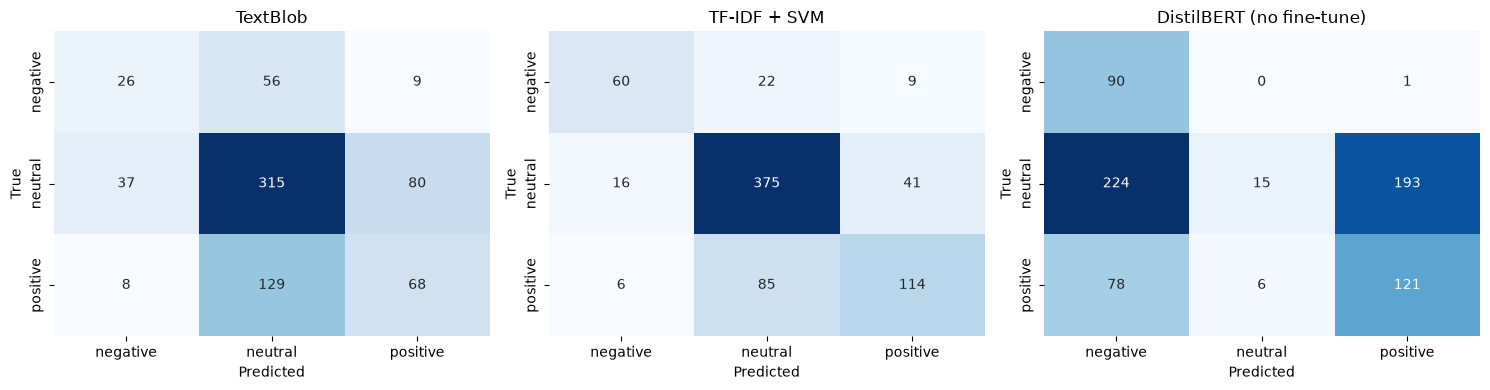

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, m) in zip(axes, results.items()):
    cm = np.array(m["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("../output/figures/baseline_confusion_matrices.png", dpi=150)
plt.show()

In [7]:
import os
os.makedirs("../output/reports", exist_ok=True)

serializable = {
    name: {k: v for k, v in m.items() if k != "classification_report"}
    for name, m in results.items()
}
with open("../output/reports/baseline_results.json", "w") as f:
    json.dump(serializable, f, indent=2)
print("Saved to output/reports/baseline_results.json")

Saved to output/reports/baseline_results.json


## Findings

- **TextBlob** relies on a generic English polarity lexicon with no notion of financial vocabulary ("loss", "decline", "growth") -- expect it to misread neutral factual statements as polarized, and financially-negative-but-lexically-neutral words as positive/neutral.
- **TF-IDF + SVM**, trained directly on our domain, should outperform TextBlob by learning financial vocabulary directly, but has no contextual/semantic understanding and will struggle with sentences whose sentiment depends on word order or negation.
- **DistilBERT (SST-2)** is a strong generic sentiment model but was trained on movie reviews, is binary (no native neutral class -- we approximate one via low-confidence predictions), and has never seen financial-domain sentences. This is the baseline the Phase 2 fine-tuned RoBERTa model most directly aims to beat, since it isolates the value of *domain-specific* fine-tuning versus just "a good pre-trained transformer."
- All three baselines struggle most with the minority `negative` class, consistent with the class imbalance found in the EDA notebook.